In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_small, ConvNeXt_Small_Weights
from torchvision.models import resnet152
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import random

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

TRAIN_DIR   = "./train"

LABEL_MAP = {
    "bedroom": 1, "Coast": 2, "Forest": 3, "Highway": 4,
    "industrial": 5, "Insidecity": 6, "kitchen": 7, "livingroom": 8,
    "Mountain": 9, "Office": 10, "OpenCountry": 11, "store": 12,
    "Street": 13, "Suburb": 14, "TallBuilding": 15,
}
CLASS_NAMES = list(LABEL_MAP.keys())
NUM_CLASSES = 15
IMG_SIZE    = 224
BATCH_SIZE  = 32
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
class SceneDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

def load_data(data_dir):
    paths, labels = [], []
    for class_name, label in LABEL_MAP.items():
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"[WARN] Missing: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(class_dir, fname))
                labels.append(label - 1)
    return paths, labels

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Recreate same 80/20 split as training notebooks (random_state=42 is critical)
train_val_paths, train_val_labels = load_data(TRAIN_DIR)
_, val_paths, _, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.2, stratify=train_val_labels, random_state=42
)


val_ds  = SceneDataset(val_paths,  val_labels,  transform=val_test_transform)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


print(f"Val: {len(val_paths)}")

Val: 300


In [4]:
convnext_model = convnext_small(weights=None)
convnext_model.classifier = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.LayerNorm(768),
    nn.Linear(768, NUM_CLASSES)
)
convnext_model.load_state_dict(torch.load("trained_cnn.pth", map_location=DEVICE))
convnext_model = convnext_model.to(DEVICE)
convnext_model.eval()
print("✓ ConvNeXt Small loaded")

✓ ConvNeXt Small loaded


In [5]:
resnet_model = resnet152(weights=None)
resnet_model.fc = nn.Linear(2048, NUM_CLASSES)
resnet_model.load_state_dict(torch.load("trained_cnn_res.pth", map_location=DEVICE))
resnet_model = resnet_model.to(DEVICE)
resnet_model.eval()
print("✓ ResNet152 loaded")

✓ ResNet152 loaded


In [6]:
def run_ensemble(loader):
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            prob_convnext = torch.softmax(convnext_model(imgs), dim=1)
            prob_resnet   = torch.softmax(resnet_model(imgs),   dim=1)
            avg_probs     = (prob_convnext + prob_resnet) / 2.0
            preds         = avg_probs.argmax(dim=1)
            all_preds.extend((preds + 1).cpu().numpy())
            all_true.extend((labels + 1).numpy())
    return np.array(all_true), np.array(all_preds)

In [7]:
val_true, val_preds = run_ensemble(val_loader)
val_acc = (val_preds == val_true).mean() * 100
print(f"Ensemble Validation Accuracy: {val_acc:.2f}%")

Ensemble Validation Accuracy: 98.67%


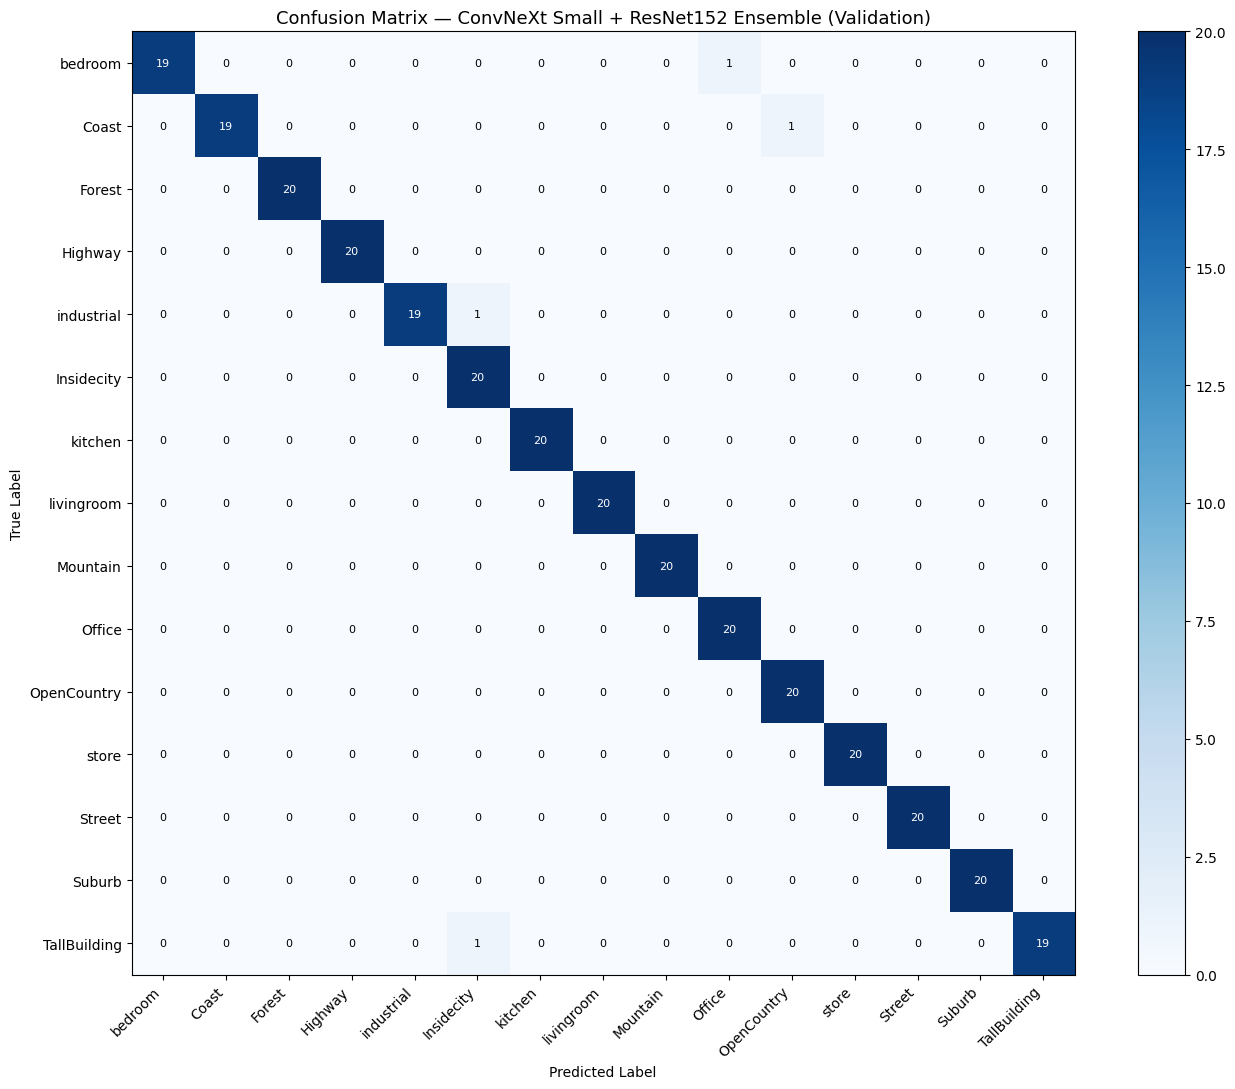

In [8]:
cm = confusion_matrix(val_true, val_preds)

plt.figure(figsize=(14, 11))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar()
plt.title("Confusion Matrix — ConvNeXt Small + ResNet152 Ensemble (Validation)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

ticks = range(len(CLASS_NAMES))
plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(ticks, CLASS_NAMES)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=8)

plt.tight_layout()
# plt.savefig("confusion_matrix_ensemble_val.png", dpi=150)
plt.show()

In [9]:
report = classification_report(val_true, val_preds, target_names=CLASS_NAMES, digits=4)
print("Classification Report — ConvNeXt Small + ResNet152 Ensemble (Validation)")
print(report)

Classification Report — ConvNeXt Small + ResNet152 Ensemble (Validation)
              precision    recall  f1-score   support

     bedroom     1.0000    0.9500    0.9744        20
       Coast     1.0000    0.9500    0.9744        20
      Forest     1.0000    1.0000    1.0000        20
     Highway     1.0000    1.0000    1.0000        20
  industrial     1.0000    0.9500    0.9744        20
  Insidecity     0.9091    1.0000    0.9524        20
     kitchen     1.0000    1.0000    1.0000        20
  livingroom     1.0000    1.0000    1.0000        20
    Mountain     1.0000    1.0000    1.0000        20
      Office     0.9524    1.0000    0.9756        20
 OpenCountry     0.9524    1.0000    0.9756        20
       store     1.0000    1.0000    1.0000        20
      Street     1.0000    1.0000    1.0000        20
      Suburb     1.0000    1.0000    1.0000        20
TallBuilding     1.0000    0.9500    0.9744        20

    accuracy                         0.9867       300
   macr